In [7]:
train_df[["jid", "reduced_formula", "refractive_index"]].to_parquet(
    "data/processed/lignn_train.parquet", index=False
)
val_df[["jid", "reduced_formula", "refractive_index"]].to_parquet(
    "data/processed/lignn_val.parquet", index=False
)
test_df[["jid", "reduced_formula", "refractive_index"]].to_parquet(
    "data/processed/lignn_test.parquet", index=False
)

In [9]:
import pandas as pd
from jarvis.db.figshare import data
from jarvis.core.atoms import Atoms

# load the split manifests you already saved
train_df = pd.read_parquet("data/processed/lignn_train.parquet")
val_df = pd.read_parquet("data/processed/lignn_val.parquet")
test_df = pd.read_parquet("data/processed/lignn_test.parquet")

# load the full structure table that contains atoms
full_df = pd.read_parquet("data/processed/ri_structure_dataset_lignn.parquet")

print(train_df.shape, val_df.shape, test_df.shape, full_df.shape)

(22630, 3) (4858, 3) (4853, 3) (32341, 141)


In [11]:
from jarvis.db.figshare import data
from jarvis.core.atoms import Atoms

# rebuild the structure lookup from JARVIS
dft3d = data("dft_3d")
structure_lookup = {x["jid"]: x["atoms"] for x in dft3d}

# attach atoms directly to each split by jid
train_df["atoms"] = train_df["jid"].map(structure_lookup)
val_df["atoms"] = val_df["jid"].map(structure_lookup)
test_df["atoms"] = test_df["jid"].map(structure_lookup)

print(train_df["atoms"].notna().mean())
print(val_df["atoms"].notna().mean())
print(test_df["atoms"].notna().mean())

# sanity check one structure
sample_atoms = Atoms.from_dict(train_df.iloc[0]["atoms"])
print(sample_atoms)
print(sample_atoms.num_atoms)
print(sample_atoms.composition)

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
1.0
1.0
1.0
System
1.0
3.566933224304235 0.0 -0.0
0.0 3.566933224304235 -0.0
-0.0 -0.0 9.397075454186664
Ti Cu Si As 
2 2 2 2 
direct
0.7500000000000001 0.7500000000000001 0.784935507022239 Ti
0.25 0.25 0.2150644929777609 Ti
0.25 0.7500000000000001 0.5 Cu
0.7500000000000001 0.25 0.5 Cu
0.25 0.7500000000000001 0.0 Si
0.7500000000000001 0.25 0.0 Si
0.7500000000000001 0.7500000000000001 0.3074869598412097 As
0.25 0.25 0.6925130401587904 As

8
OrderedDict({'Ti': 2, 'Cu': 2, 'Si': 2, 'As': 2})


In [12]:
train_df.to_parquet("data/processed/lignn_train_with_atoms.parquet", index=False)
val_df.to_parquet("data/processed/lignn_val_with_atoms.parquet", index=False)
test_df.to_parquet("data/processed/lignn_test_with_atoms.parquet", index=False)

In [14]:
import numpy as np
from jarvis.core.atoms import Atoms

def to_native(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_native(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_native(v) for v in obj]
    return obj

raw_atoms = train_df.iloc[0]["atoms"]
clean_atoms = to_native(raw_atoms)

sample_atoms = Atoms.from_dict(clean_atoms)
print(sample_atoms)
print(sample_atoms.num_atoms)
print(sample_atoms.composition)

System
1.0
3.566933224304235 0.0 -0.0
0.0 3.566933224304235 -0.0
-0.0 -0.0 9.397075454186664
Ti Cu Si As 
2 2 2 2 
direct
0.7500000000000001 0.7500000000000001 0.784935507022239 Ti
0.25 0.25 0.2150644929777609 Ti
0.25 0.7500000000000001 0.5 Cu
0.7500000000000001 0.25 0.5 Cu
0.25 0.7500000000000001 0.0 Si
0.7500000000000001 0.25 0.0 Si
0.7500000000000001 0.7500000000000001 0.3074869598412097 As
0.25 0.25 0.6925130401587904 As

8
OrderedDict({'Ti': 2, 'Cu': 2, 'Si': 2, 'As': 2})


In [15]:
train_df["atoms"] = train_df["atoms"].apply(to_native)
val_df["atoms"] = val_df["atoms"].apply(to_native)
test_df["atoms"] = test_df["atoms"].apply(to_native)

train_df.to_parquet("data/processed/lignn_train_with_atoms_clean.parquet", index=False)
val_df.to_parquet("data/processed/lignn_val_with_atoms_clean.parquet", index=False)
test_df.to_parquet("data/processed/lignn_test_with_atoms_clean.parquet", index=False)

print(train_df.shape, val_df.shape, test_df.shape)

(22630, 4) (4858, 4) (4853, 4)


In [17]:
import numpy as np
from jarvis.db.figshare import data
from jarvis.core.atoms import Atoms

# rebuild fresh lookup from JARVIS
dft3d = data("dft_3d")
structure_lookup = {x["jid"]: x["atoms"] for x in dft3d}

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        obj = obj.tolist()
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [deep_clean(v) for v in obj]
    return obj

# take one jid and rebuild atoms directly from JARVIS
jid = train_df.iloc[0]["jid"]
raw_atoms = structure_lookup[jid]
clean_atoms = deep_clean(raw_atoms)

print(type(clean_atoms))
print(clean_atoms.keys())

sample_atoms = Atoms.from_dict(clean_atoms)
print(sample_atoms)
print(sample_atoms.num_atoms)
print(sample_atoms.composition)

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
<class 'dict'>
dict_keys(['lattice_mat', 'coords', 'elements', 'abc', 'angles', 'cartesian', 'props'])
System
1.0
3.566933224304235 0.0 -0.0
0.0 3.566933224304235 -0.0
-0.0 -0.0 9.397075454186664
Ti Cu Si As 
2 2 2 2 
direct
0.7500000000000001 0.7500000000000001 0.784935507022239 Ti
0.25 0.25 0.2150644929777609 Ti
0.25 0.7500000000000001 0.5 Cu
0.7500000000000001 0.25 0.5 Cu
0.25 0.7500000000000001 0.0 Si
0.7500000000000001 0.25 0.0 Si
0.7500000000000001 0.7500000000000001 0.3074869598412097 As
0.25 0.25 0.6925130401587904 As

8
OrderedDict({'Ti': 2, 'Cu': 2, 'Si': 2, 'As': 2})


In [18]:
train_df["atoms"] = train_df["jid"].map(lambda x: deep_clean(structure_lookup[x]))
val_df["atoms"] = val_df["jid"].map(lambda x: deep_clean(structure_lookup[x]))
test_df["atoms"] = test_df["jid"].map(lambda x: deep_clean(structure_lookup[x]))

In [19]:
train_df.to_parquet("data/processed/lignn_train_ready.parquet", index=False)
val_df.to_parquet("data/processed/lignn_val_ready.parquet", index=False)
test_df.to_parquet("data/processed/lignn_test_ready.parquet", index=False)

In [20]:
Atoms.from_dict(clean_atoms)

System
1.0
3.566933224304235 0.0 -0.0
0.0 3.566933224304235 -0.0
-0.0 -0.0 9.397075454186664
Ti Cu Si As 
2 2 2 2 
direct
0.7500000000000001 0.7500000000000001 0.784935507022239 Ti
0.25 0.25 0.2150644929777609 Ti
0.25 0.7500000000000001 0.5 Cu
0.7500000000000001 0.25 0.5 Cu
0.25 0.7500000000000001 0.0 Si
0.7500000000000001 0.25 0.0 Si
0.7500000000000001 0.7500000000000001 0.3074869598412097 As
0.25 0.25 0.6925130401587904 As

In [22]:
import numpy as np
from jarvis.core.atoms import Atoms

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

raw_atoms = train_df.iloc[0]["atoms"]
clean_atoms = deep_clean(raw_atoms)

sample_atoms = Atoms.from_dict(clean_atoms)
print(sample_atoms)
print(sample_atoms.num_atoms)
print(sample_atoms.composition)

System
1.0
3.566933224304235 0.0 -0.0
0.0 3.566933224304235 -0.0
-0.0 -0.0 9.397075454186664
Ti Cu Si As 
2 2 2 2 
direct
0.7500000000000001 0.7500000000000001 0.784935507022239 Ti
0.25 0.25 0.2150644929777609 Ti
0.25 0.7500000000000001 0.5 Cu
0.7500000000000001 0.25 0.5 Cu
0.25 0.7500000000000001 0.0 Si
0.7500000000000001 0.25 0.0 Si
0.7500000000000001 0.7500000000000001 0.3074869598412097 As
0.25 0.25 0.6925130401587904 As

8
OrderedDict({'Ti': 2, 'Cu': 2, 'Si': 2, 'As': 2})


In [23]:
train_df["atoms"] = train_df["atoms"].apply(deep_clean)
val_df["atoms"] = val_df["atoms"].apply(deep_clean)
test_df["atoms"] = test_df["atoms"].apply(deep_clean)

train_df.to_parquet("data/processed/lignn_train_ready_final.parquet", index=False)
val_df.to_parquet("data/processed/lignn_val_ready_final.parquet", index=False)
test_df.to_parquet("data/processed/lignn_test_ready_final.parquet", index=False)

In [24]:
import numpy as np
from jarvis.core.atoms import Atoms

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

# test one row first
clean_atoms = deep_clean(train_df.iloc[0]["atoms"])
sample_atoms = Atoms.from_dict(clean_atoms)
print(sample_atoms)
print(sample_atoms.num_atoms)
print(sample_atoms.composition)

# clean all rows
train_df["atoms"] = train_df["atoms"].apply(deep_clean)
val_df["atoms"] = val_df["atoms"].apply(deep_clean)
test_df["atoms"] = test_df["atoms"].apply(deep_clean)

# save final files
train_df.to_parquet("data/processed/lignn_train_ready_final.parquet", index=False)
val_df.to_parquet("data/processed/lignn_val_ready_final.parquet", index=False)
test_df.to_parquet("data/processed/lignn_test_ready_final.parquet", index=False)

print(train_df.shape, val_df.shape, test_df.shape)

System
1.0
3.566933224304235 0.0 -0.0
0.0 3.566933224304235 -0.0
-0.0 -0.0 9.397075454186664
Ti Cu Si As 
2 2 2 2 
direct
0.7500000000000001 0.7500000000000001 0.784935507022239 Ti
0.25 0.25 0.2150644929777609 Ti
0.25 0.7500000000000001 0.5 Cu
0.7500000000000001 0.25 0.5 Cu
0.25 0.7500000000000001 0.0 Si
0.7500000000000001 0.25 0.0 Si
0.7500000000000001 0.7500000000000001 0.3074869598412097 As
0.25 0.25 0.6925130401587904 As

8
OrderedDict({'Ti': 2, 'Cu': 2, 'Si': 2, 'As': 2})
(22630, 4) (4858, 4) (4853, 4)


In [26]:
import numpy as np
import pandas as pd
from jarvis.db.figshare import data
from jarvis.core.atoms import Atoms

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

# reload the split manifests
train_df = pd.read_parquet("data/processed/lignn_train_with_atoms_clean.parquet")
val_df = pd.read_parquet("data/processed/lignn_val_with_atoms_clean.parquet")
test_df = pd.read_parquet("data/processed/lignn_test_with_atoms_clean.parquet")

# rebuild fresh structures from JARVIS
dft3d = data("dft_3d")
structure_lookup = {x["jid"]: x["atoms"] for x in dft3d}

train_df["atoms"] = train_df["jid"].map(lambda x: deep_clean(structure_lookup[x]))
val_df["atoms"] = val_df["jid"].map(lambda x: deep_clean(structure_lookup[x]))
test_df["atoms"] = test_df["jid"].map(lambda x: deep_clean(structure_lookup[x]))

# test one structure from the fresh lookup
sample_atoms = Atoms.from_dict(train_df.iloc[0]["atoms"])
print(sample_atoms)
print(sample_atoms.num_atoms)
print(sample_atoms.composition)

# save a fresh version
train_df.to_parquet("data/processed/lignn_train_ready_v2.parquet", index=False)
val_df.to_parquet("data/processed/lignn_val_ready_v2.parquet", index=False)
test_df.to_parquet("data/processed/lignn_test_ready_v2.parquet", index=False)

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
System
1.0
3.566933224304235 0.0 -0.0
0.0 3.566933224304235 -0.0
-0.0 -0.0 9.397075454186664
Ti Cu Si As 
2 2 2 2 
direct
0.7500000000000001 0.7500000000000001 0.784935507022239 Ti
0.25 0.25 0.2150644929777609 Ti
0.25 0.7500000000000001 0.5 Cu
0.7500000000000001 0.25 0.5 Cu
0.25 0.7500000000000001 0.0 Si
0.7500000000000001 0.25 0.0 Si
0.7500000000000001 0.7500000000000001 0.3074869598412097 As
0.25 0.25 0.6925130401587904 As

8
OrderedDict({'Ti': 2, 'Cu': 2, 'Si': 2, 'As': 2})


In [42]:
print(graph["edge_index"][:, :10])
print(graph["edge_attr"][:10])

[[0 0 0 0 0 0 1 1 1 1]
 [1 2 3 4 6 7 0 2 3 4]]
[[5.3748083]
 [3.098029 ]
 [5.258541 ]
 [3.0637307]
 [5.334343 ]
 [3.1031487]
 [5.3748083]
 [3.1082604]
 [3.06373  ]
 [4.305161 ]]


In [43]:
def build_graph_row(row):
    return atoms_dict_to_tiny_graph(
        row["atoms"],
        cutoff=6.0
    )

proto_train["graph"] = proto_train.apply(
    build_graph_row,
    axis=1
)

proto_val["graph"] = proto_val.apply(
    build_graph_row,
    axis=1
)

print(len(proto_train))
print(len(proto_val))
print(proto_train.iloc[0]["graph"].keys())

500
200
dict_keys(['num_nodes', 'node_z', 'cart_coords', 'edge_index', 'edge_attr'])


In [44]:
proto_train["n_nodes"] = (
    proto_train["graph"]
    .apply(lambda g: g["num_nodes"])
)

proto_train["n_edges"] = (
    proto_train["graph"]
    .apply(lambda g: g["edge_index"].shape[1])
)

proto_train[
    ["n_nodes", "n_edges"]
].describe()

,n_nodes,n_edges
count,500.000000,500.000000
mean,9.120000,89.056000
std,7.345578,138.257713
min,1.000000,0.000000
25%,4.000000,10.000000
50%,6.000000,22.000000
75%,12.000000,100.500000
max,40.000000,784.000000


In [45]:
bad_nodes = (proto_train["n_nodes"] < 2).sum()
bad_edges = (proto_train["n_edges"] == 0).sum()

print("graphs with <2 nodes:", bad_nodes)
print("graphs with 0 edges:", bad_edges)
print("fraction with 0 edges:", (proto_train["n_edges"] == 0).mean())

graphs with <2 nodes: 1
graphs with 0 edges: 3
fraction with 0 edges: 0.006


In [46]:
proto_train_clean = proto_train[(proto_train["n_nodes"] >= 2) & (proto_train["n_edges"] > 0)].copy()
proto_val_clean = proto_val[(proto_val["n_nodes"] >= 2) & (proto_val["n_edges"] > 0)].copy()

print(proto_train_clean.shape, proto_val_clean.shape)
print(proto_train_clean[["jid", "refractive_index", "n_nodes", "n_edges"]].head())

KeyError: 'n_nodes'

In [47]:
# Rebuild graph stats if needed
if "graph" not in proto_train.columns:
    proto_train["graph"] = proto_train.apply(
        lambda row: atoms_dict_to_tiny_graph(row["atoms"], cutoff=6.0),
        axis=1
    )

if "graph" not in proto_val.columns:
    proto_val["graph"] = proto_val.apply(
        lambda row: atoms_dict_to_tiny_graph(row["atoms"], cutoff=6.0),
        axis=1
    )

proto_train["n_nodes"] = proto_train["graph"].apply(lambda g: g["num_nodes"])
proto_train["n_edges"] = proto_train["graph"].apply(lambda g: g["edge_index"].shape[1])

proto_val["n_nodes"] = proto_val["graph"].apply(lambda g: g["num_nodes"])
proto_val["n_edges"] = proto_val["graph"].apply(lambda g: g["edge_index"].shape[1])

print(proto_train[["jid", "refractive_index", "n_nodes", "n_edges"]].head())
print(proto_train[["n_nodes", "n_edges"]].describe())

               jid  refractive_index  n_nodes  n_edges
217    JVASP-91891         13.835046        8       54
1114   JVASP-69361          8.732691        4       10
11137  JVASP-29905          4.204525       32      784
6626   JVASP-16069          8.202136        5       20
7898   JVASP-58337          3.047360       12       68
          n_nodes     n_edges
count  500.000000  500.000000
mean     9.120000   89.056000
std      7.345578  138.257713
min      1.000000    0.000000
25%      4.000000   10.000000
50%      6.000000   22.000000
75%     12.000000  100.500000
max     40.000000  784.000000


In [48]:
proto_train_clean = proto_train[(proto_train["n_nodes"] >= 2) & (proto_train["n_edges"] > 0)].copy()
proto_val_clean = proto_val[(proto_val["n_nodes"] >= 2) & (proto_val["n_edges"] > 0)].copy()

print(proto_train_clean.shape, proto_val_clean.shape)
print(proto_train_clean[["jid", "refractive_index", "n_nodes", "n_edges"]].head())

(497, 13) (199, 13)
               jid  refractive_index  n_nodes  n_edges
217    JVASP-91891         13.835046        8       54
1114   JVASP-69361          8.732691        4       10
11137  JVASP-29905          4.204525       32      784
6626   JVASP-16069          8.202136        5       20
7898   JVASP-58337          3.047360       12       68


In [50]:
# Save a lightweight manifest only
proto_train_manifest = proto_train_clean[["jid", "refractive_index", "n_nodes", "n_edges"]].copy()
proto_val_manifest = proto_val_clean[["jid", "refractive_index", "n_nodes", "n_edges"]].copy()

proto_train_manifest.to_parquet("data/processed/lignn_train_proto_manifest.parquet", index=False)
proto_val_manifest.to_parquet("data/processed/lignn_val_proto_manifest.parquet", index=False)

print(proto_train_manifest.shape, proto_val_manifest.shape)

(497, 4) (199, 4)


In [51]:
import os
print(os.path.exists("data/processed/lignn_train_proto_manifest.parquet"))
print(os.path.exists("data/processed/lignn_val_proto_manifest.parquet"))

True
True


In [52]:
# Build in-memory graph/target pairs for the prototype set
train_examples = []
val_examples = []

for _, row in proto_train_clean.iterrows():
    train_examples.append({
        "jid": row["jid"],
        "refractive_index": float(row["refractive_index"]),
        "graph": row["graph"],
    })

for _, row in proto_val_clean.iterrows():
    val_examples.append({
        "jid": row["jid"],
        "refractive_index": float(row["refractive_index"]),
        "graph": row["graph"],
    })

print(len(train_examples), len(val_examples))
print(train_examples[0].keys())
print(train_examples[0]["jid"], train_examples[0]["refractive_index"])
print(train_examples[0]["graph"].keys())

497 199
dict_keys(['jid', 'refractive_index', 'graph'])
JVASP-91891 13.835046078708954
dict_keys(['num_nodes', 'node_z', 'cart_coords', 'edge_index', 'edge_attr'])


In [53]:
g = train_examples[0]["graph"]

print("num_nodes:", g["num_nodes"])
print("node_z:", g["node_z"])
print("cart_coords shape:", g["cart_coords"].shape)
print("edge_index shape:", g["edge_index"].shape)
print("edge_attr shape:", g["edge_attr"].shape)

num_nodes: 8
node_z: [12. 12. 12. 12. 12. 12. 12. 26.]
cart_coords shape: (8, 3)
edge_index shape: (2, 54)
edge_attr shape: (54, 1)


In [54]:
mini_train = train_examples[:64]
mini_val = val_examples[:16]

print(len(mini_train), len(mini_val))

64 16


In [55]:
from jarvis.core.atoms import Atoms
from pymatgen.core import Structure
import numpy as np

# take one prototype structure
sample_ad = proto_train_clean.iloc[0]["atoms"]

# clean once more just to be safe
sample_ad = deep_clean(sample_ad)

# build jarvis atoms object
atoms = Atoms.from_dict(sample_ad)
print(atoms)
print(atoms.num_atoms)
print(atoms.composition)

System
1.0
6.206290056784209 -7.1749478e-09 -0.0
-3.103145540813689 5.374804084551666 -0.0
-0.0 -0.0 4.902064994104166
Mg Fe 
7 1 
direct
0.16721622970927563 0.8336081148546415 0.25 Mg
0.6663918851453585 0.3327837702907244 0.25 Mg
0.6663918851453585 0.8336081148546415 0.25 Mg
0.3247381684922361 0.1752618315071031 0.7500000000000001 Mg
0.32473816849374243 0.6494763369866322 0.7500000000000001 Mg
0.8505236630140357 0.1752618315062575 0.7500000000000001 Mg
0.8333330000000033 0.6666669999999968 0.7500000000000001 Mg
0.16666699999999682 0.3333330000000032 0.25 Fe

8
OrderedDict({'Mg': 7, 'Fe': 1})


In [56]:
lattice = np.asarray(sample_ad["lattice_mat"], dtype=float)
coords = np.asarray(sample_ad["coords"], dtype=float)
elements = [str(x) for x in sample_ad["elements"]]
cartesian = bool(sample_ad["cartesian"])

structure = Structure(
    lattice=lattice,
    species=elements,
    coords=coords,
    coords_are_cartesian=cartesian,
)

print(structure)
print(len(structure))

Full Formula (Mg7 Fe1)
Reduced Formula: Mg7Fe
abc   :   6.206290   6.206290   4.902065
angles:  90.000000  90.000000 120.000008
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Mg    0.167215  0.833607  0.25
  1  Mg    0.666392  0.332784  0.25
  2  Mg    0.666391  0.833607  0.25
  3  Mg    0.324738  0.175262  0.749999
  4  Mg    0.324737  0.649476  0.749999
  5  Mg    0.850523  0.175262  0.749999
  6  Mg    0.833332  0.666666  0.749999
  7  Fe    0.166667  0.333333  0.25
8


In [58]:
from jarvis.core.atoms import Atoms
import numpy as np

sample_ad = proto_train_clean.iloc[0]["atoms"]
sample_ad = deep_clean(sample_ad)

atoms = Atoms.from_dict(sample_ad)
print(atoms)
print(atoms.num_atoms)
print(atoms.composition)

System
1.0
6.206290056784209 -7.1749478e-09 -0.0
-3.103145540813689 5.374804084551666 -0.0
-0.0 -0.0 4.902064994104166
Mg Fe 
7 1 
direct
0.16721622970927563 0.8336081148546415 0.25 Mg
0.6663918851453585 0.3327837702907244 0.25 Mg
0.6663918851453585 0.8336081148546415 0.25 Mg
0.3247381684922361 0.1752618315071031 0.7500000000000001 Mg
0.32473816849374243 0.6494763369866322 0.7500000000000001 Mg
0.8505236630140357 0.1752618315062575 0.7500000000000001 Mg
0.8333330000000033 0.6666669999999968 0.7500000000000001 Mg
0.16666699999999682 0.3333330000000032 0.25 Fe

8
OrderedDict({'Mg': 7, 'Fe': 1})


In [59]:
import os
import csv
import numpy as np
import pandas as pd
from pathlib import Path
from pymatgen.core import Structure
from pymatgen.io.vasp.inputs import Poscar

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

def atoms_dict_to_structure(ad):
    ad = deep_clean(ad)
    lattice = np.asarray(ad["lattice_mat"], dtype=float)
    coords = np.asarray(ad["coords"], dtype=float)
    species = [str(x) for x in ad["elements"]]
    cartesian = bool(ad["cartesian"])
    return Structure(
        lattice=lattice,
        species=species,
        coords=coords,
        coords_are_cartesian=cartesian,
    )

def write_alignn_dataset(df, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for _, row in df.iterrows():
        jid = row["jid"]
        target = float(row["refractive_index"])
        struct = atoms_dict_to_structure(row["atoms"])

        fname = f"POSCAR-{jid}"
        Poscar(struct).write_file(str(out_dir / fname))
        rows.append((fname, target))

    with open(out_dir / "id_prop.csv", "w", newline="") as f:
        writer = csv.writer(f)
        for fname, target in rows:
            writer.writerow([fname, target])

    return len(rows)

train_dir = "data/processed/alignn_proto_train"
val_dir = "data/processed/alignn_proto_val"

n_train = write_alignn_dataset(proto_train_clean, train_dir)
n_val = write_alignn_dataset(proto_val_clean, val_dir)

print("train written:", n_train)
print("val written:", n_val)

/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)


train written: 497
val written: 199


In [60]:
print(os.path.exists(f"{train_dir}/id_prop.csv"))
print(os.path.exists(f"{train_dir}/POSCAR-{proto_train_clean.iloc[0]['jid']}"))

with open(f"{train_dir}/id_prop.csv", "r") as f:
    print(f.readline().strip())

True
True
POSCAR-JVASP-91891,13.835046078708954


In [61]:
import os
import pandas as pd

train_dir = "data/processed/alignn_proto_train"
val_dir = "data/processed/alignn_proto_val"

train_ids = pd.read_csv(f"{train_dir}/id_prop.csv", header=None)
val_ids = pd.read_csv(f"{val_dir}/id_prop.csv", header=None)

print("train rows:", len(train_ids))
print("val rows:", len(val_ids))

train_poscars = [f for f in os.listdir(train_dir) if f.startswith("POSCAR-")]
val_poscars = [f for f in os.listdir(val_dir) if f.startswith("POSCAR-")]

print("train POSCAR files:", len(train_poscars))
print("val POSCAR files:", len(val_poscars))

print(train_ids.head())

train rows: 497
val rows: 199
train POSCAR files: 497
val POSCAR files: 199
                    0          1
0  POSCAR-JVASP-91891  13.835046
1  POSCAR-JVASP-69361   8.732691
2  POSCAR-JVASP-29905   4.204525
3  POSCAR-JVASP-16069   8.202136
4  POSCAR-JVASP-58337   3.047360


In [62]:
sample_file = os.path.join(train_dir, train_poscars[0])
with open(sample_file, "r") as f:
    for _ in range(12):
        print(f.readline().rstrip())

U1 In1 Au2
1.0
   4.3124265341545653    0.0000000014883289    2.4897806354436902
   1.4374751808579416    4.0657941597338523    2.4897806354436902
  -0.0000000000000000    0.0000000000000000    4.9795612708873804
U In Au
1 1 2
direct
   0.5000011311730758    0.4999994882645283    0.4999994350604444 U
   0.0000000000000000    0.0000000000000000    0.0000000000000000 In
   0.2500005655865379    0.2499997441322641    0.2499997175302222 Au
   0.7500016967596136    0.7499992323967924    0.7499991525906666 Au


In [64]:
import numpy as np
import pandas as pd
from jarvis.db.figshare import data
from jarvis.core.atoms import Atoms

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

# rebuild fresh JARVIS lookup
dft3d = data("dft_3d")
structure_lookup = {x["jid"]: x["atoms"] for x in dft3d}

# sample a small prototype test set
proto_test = test_lignn.sample(100, random_state=42).copy()

# attach fresh atoms from jid
proto_test["atoms"] = proto_test["jid"].map(lambda x: deep_clean(structure_lookup[x]))

# sanity check one row
sample_atoms = Atoms.from_dict(proto_test.iloc[0]["atoms"])
print(sample_atoms)
print(sample_atoms.num_atoms)
print(sample_atoms.composition)

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
System
1.0
7.417377278603865 0.0 -0.0
0.0 7.417377278603865 -0.0
-0.0 -0.0 6.449096196296884
Rb Pd F 
6 2 10 
direct
0.0 0.0 0.0 Rb
0.5 0.5 0.0 Rb
0.3283603430314972 0.8283603430314971 0.5 Rb
0.8283603430314971 0.6716396569685029 0.5 Rb
0.17163965696850292 0.3283603430314972 0.5 Rb
0.6716396569685029 0.17163965696850292 0.5 Rb
0.5 0.0 0.0 Pd
0.0 0.5 0.0 Pd
0.8640031550815376 0.3640031550815371 0.2125422287969896 F
0.3640031550815371 0.1359968449184627 0.2125422287969896 F
0.6359968449184625 0.8640031550815376 0.2125422287969896 F
0.1359968449184627 0.6359968449184625 0.2125422287969896 F
0.1359968449184627 0.6359968449184625 0.7874577712030102 F
0.3640031550815371 0.1359968449184627 0.7874577712030102 F
0.8640031550815376 0.3640031550815371 0.7874577712030102 F
0.0 0.0 0.5 F
0.6359968449184625 0.86400

In [65]:
proto_all = pd.concat(
    [
        proto_train_clean[["jid", "refractive_index", "atoms"]],
        proto_val_clean[["jid", "refractive_index", "atoms"]],
        proto_test[["jid", "refractive_index", "atoms"]],
    ],
    axis=0,
    ignore_index=True,
)

print(proto_all.shape)
print(proto_all["atoms"].notna().mean())

(796, 3)
1.0


In [66]:
import csv
from pathlib import Path
import numpy as np
from pymatgen.core import Structure
from pymatgen.io.vasp.inputs import Poscar

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

def atoms_to_structure(ad):
    ad = deep_clean(ad)
    lattice = np.asarray(ad["lattice_mat"], dtype=float)
    coords = np.asarray(ad["coords"], dtype=float)
    species = [str(x) for x in ad["elements"]]
    cartesian = bool(ad["cartesian"])
    return Structure(
        lattice=lattice,
        species=species,
        coords=coords,
        coords_are_cartesian=cartesian,
    )

def write_alignn_dir(df, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for _, row in df.iterrows():
        jid = row["jid"]
        target = float(row["refractive_index"])
        struct = atoms_to_structure(row["atoms"])
        fname = f"POSCAR-{jid}"
        Poscar(struct).write_file(str(out_dir / fname))
        rows.append((fname, target))

    with open(out_dir / "id_prop.csv", "w", newline="") as f:
        writer = csv.writer(f)
        for fname, target in rows:
            writer.writerow([fname, target])

    return len(rows)

alignn_root = "data/processed/alignn_proto_all"
n_written = write_alignn_dir(proto_all, alignn_root)

print("structures written:", n_written)
print("id_prop exists:", (Path(alignn_root) / "id_prop.csv").exists())
print("poscars written:", len([p for p in Path(alignn_root).iterdir() if p.name.startswith("POSCAR-")]))

structures written: 796
id_prop exists: True
poscars written: 796


In [67]:
sample_file = Path(alignn_root) / f"POSCAR-{proto_all.iloc[0]['jid']}"
with open(sample_file, "r") as f:
    for _ in range(10):
        print(f.readline().rstrip())

Mg7 Fe1
1.0
   6.2062900567842094   -0.0000000071749478   -0.0000000000000000
  -3.1031455408136890    5.3748040845516663   -0.0000000000000000
  -0.0000000000000000   -0.0000000000000000    4.9020649941041663
Mg Fe
7 1
direct
   0.1672153126000464    0.8336074815821350    0.2499997453061020 Mg
   0.6663915139410744    0.3327835182831800    0.2499997453061020 Mg


In [68]:
import csv
import json
import numpy as np
import pandas as pd
from pathlib import Path
from pymatgen.core import Structure
from pymatgen.io.vasp.inputs import Poscar
from jarvis.db.figshare import data

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

# Load your manifests
train_manifest = pd.read_parquet("data/processed/lignn_train_manifest.parquet")
val_manifest = pd.read_parquet("data/processed/lignn_val_manifest.parquet")
test_manifest = pd.read_parquet("data/processed/lignn_test_manifest.parquet")

# Prototype sizes
proto_train = train_manifest.sample(500, random_state=42).copy()
proto_val = val_manifest.sample(200, random_state=42).copy()
proto_test = test_manifest.sample(100, random_state=42).copy()

# Fresh JARVIS structure lookup
dft3d = data("dft_3d")
structure_lookup = {x["jid"]: x["atoms"] for x in dft3d}

# Attach fresh atoms from jid
proto_train["atoms"] = proto_train["jid"].map(lambda x: deep_clean(structure_lookup[x]))
proto_val["atoms"] = proto_val["jid"].map(lambda x: deep_clean(structure_lookup[x]))
proto_test["atoms"] = proto_test["jid"].map(lambda x: deep_clean(structure_lookup[x]))

proto_all = pd.concat(
    [
        proto_train[["jid", "refractive_index", "atoms"]],
        proto_val[["jid", "refractive_index", "atoms"]],
        proto_test[["jid", "refractive_index", "atoms"]],
    ],
    axis=0,
    ignore_index=True,
)

print(proto_all.shape)
print(proto_all["atoms"].notna().mean())

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
(800, 3)
1.0


In [69]:
def atoms_to_structure(ad):
    ad = deep_clean(ad)
    lattice = np.asarray(ad["lattice_mat"], dtype=float)
    coords = np.asarray(ad["coords"], dtype=float)
    species = [str(x) for x in ad["elements"]]
    cartesian = bool(ad["cartesian"])
    return Structure(
        lattice=lattice,
        species=species,
        coords=coords,
        coords_are_cartesian=cartesian,
    )

def write_alignn_dir(df, out_dir):
    out_dir = Path(out_dir)
    if out_dir.exists():
        for p in out_dir.iterdir():
            if p.is_file():
                p.unlink()
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for _, row in df.iterrows():
        jid = row["jid"]
        target = float(row["refractive_index"])
        struct = atoms_to_structure(row["atoms"])
        fname = f"POSCAR-{jid}"
        Poscar(struct).write_file(str(out_dir / fname))
        rows.append((fname, target))

    with open(out_dir / "id_prop.csv", "w", newline="") as f:
        writer = csv.writer(f)
        for fname, target in rows:
            writer.writerow([fname, target])

    return len(rows)

alignn_root = "data/processed/alignn_proto_all"
n_written = write_alignn_dir(proto_all, alignn_root)

print("structures written:", n_written)
print("id_prop exists:", (Path(alignn_root) / "id_prop.csv").exists())
print("poscars written:", len([p for p in Path(alignn_root).iterdir() if p.name.startswith("POSCAR-")]))

structures written: 800
id_prop exists: True
poscars written: 800


In [70]:
sample_file = Path(alignn_root) / f"POSCAR-{proto_all.iloc[0]['jid']}"
with open(sample_file, "r") as f:
    for _ in range(10):
        print(f.readline().rstrip())

Mg7 Fe1
1.0
   6.2062900567842094   -0.0000000071749478   -0.0000000000000000
  -3.1031455408136890    5.3748040845516663   -0.0000000000000000
  -0.0000000000000000   -0.0000000000000000    4.9020649941041663
Mg Fe
7 1
direct
   0.1672153126000464    0.8336074815821350    0.2499997453061020 Mg
   0.6663915139410744    0.3327835182831800    0.2499997453061020 Mg


In [71]:
config = {
    "version": "prototype",
    "dataset": "user_data",
    "target": "target",
    "atom_features": "cgcnn",
    "neighbor_strategy": "k-nearest",
    "id_tag": "jid",
    "dtype": "float32",
    "random_seed": 42,
    "classification_threshold": None,
    "n_val": len(proto_val),
    "n_test": len(proto_test),
    "n_train": len(proto_train),
    "train_ratio": 0.8,
    "val_ratio": 0.1,
    "test_ratio": 0.1,
    "target_multiplication_factor": None,
    "epochs": 5,
    "batch_size": 16,
    "weight_decay": 1e-5,
    "learning_rate": 1e-3,
    "filename": "alignn_proto",
    "warmup_steps": 2000,
    "criterion": "mse",
    "optimizer": "adamw",
    "scheduler": "onecycle",
    "pin_memory": False,
    "save_dataloader": False,
    "write_checkpoint": True,
    "write_predictions": True,
    "store_outputs": True,
    "progress": True,
    "log_tensorboard": False,
    "standard_scalar_and_pca": False,
    "use_canonize": True,
    "num_workers": 0,
    "cutoff": 8.0,
    "cutoff_extra": 3.0,
    "max_neighbors": 12,
    "keep_data_order": True,
    "normalize_graph_level_loss": False,
    "distributed": False,
    "data_parallel": False,
    "n_early_stopping": None,
    "output_dir": "data/processed/alignn_proto_out",
    "use_lmdb": True,
    "model": {
        "name": "alignn_atomwise",
        "alignn_layers": 4,
        "gcn_layers": 4,
        "atom_input_features": 92,
        "edge_input_features": 80,
        "triplet_input_features": 40,
        "embedding_features": 64,
        "hidden_features": 256,
        "output_features": 1,
        "grad_multiplier": -1,
        "calculate_gradient": False,
        "atomwise_output_features": 0,
        "graphwise_weight": 1.0,
        "gradwise_weight": 1.0,
        "stresswise_weight": 0.0,
        "atomwise_weight": 0.0,
        "link": "identity",
        "zero_inflated": False,
        "classification": False,
        "force_mult_natoms": False,
        "energy_mult_natoms": False,
        "include_pos_deriv": False,
        "use_cutoff_function": False,
        "inner_cutoff": 3.0,
        "stress_multiplier": 1.0,
        "add_reverse_forces": True,
        "lg_on_fly": True,
        "batch_stress": True,
        "multiply_cutoff": False,
        "use_penalty": True,
        "extra_features": 0,
        "exponent": 5,
        "additional_output_features": 400,
        "additional_output_weight": 0.1,
        "penalty_factor": 0.1,
        "penalty_threshold": 1.0
    }
}

config_path = "data/processed/alignn_proto_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(config_path)
print(Path(config_path).exists())

data/processed/alignn_proto_config.json
True


In [72]:
print("Run this next if ALIGNN is installed and train_alignn.py is on PATH:")
print(
    "train_alignn.py --root_dir data/processed/alignn_proto_all "
    "--config data/processed/alignn_proto_config.json "
    "--output_dir data/processed/alignn_proto_out"
)

Run this next if ALIGNN is installed and train_alignn.py is on PATH:
train_alignn.py --root_dir data/processed/alignn_proto_all --config data/processed/alignn_proto_config.json --output_dir data/processed/alignn_proto_out


In [73]:
train_alignn.py --root_dir data/processed/alignn_proto_all --config data/processed/alignn_proto_config.json --output_dir data/processed/alignn_proto_out

SyntaxError: invalid syntax (986664313.py, line 1)

In [75]:
import alignn

print(alignn.__file__)

ModuleNotFoundError: No module named 'alignn'

In [76]:
from pathlib import Path
import shutil
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.io.cif import CifWriter

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

def atoms_dict_to_structure(ad):
    ad = deep_clean(ad)
    lattice = np.asarray(ad["lattice_mat"], dtype=float)
    coords = np.asarray(ad["coords"], dtype=float)
    species = [str(x) for x in ad["elements"]]
    return Structure(
        lattice=lattice,
        species=species,
        coords=coords,
        coords_are_cartesian=bool(ad["cartesian"]),
    )

In [77]:
# Rebuild a small prototype set
# Assumes proto_train_clean and proto_val_clean already exist in memory and have an "atoms" column.
proto_test = test_lignn.sample(100, random_state=42).copy()

# Fresh JARVIS lookup if needed
from jarvis.db.figshare import data
dft3d = data("dft_3d")
structure_lookup = {x["jid"]: x["atoms"] for x in dft3d}

proto_test["atoms"] = proto_test["jid"].map(lambda x: deep_clean(structure_lookup[x]))

proto_all = pd.concat(
    [
        proto_train_clean[["jid", "refractive_index", "atoms"]],
        proto_val_clean[["jid", "refractive_index", "atoms"]],
        proto_test[["jid", "refractive_index", "atoms"]],
    ],
    ignore_index=True,
)

print(proto_all.shape)
print(proto_all["atoms"].notna().mean())

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
(796, 3)
1.0


In [78]:
# Write CGCNN-style dataset
cgcnn_root = Path("/Users/anitanam/optical_materials_ml/notebooks/data/processed/cgcnn_proto_all")
cgcnn_root.mkdir(parents=True, exist_ok=True)

# Copy atom_init.json from the CGCNN repo sample data
# Adjust this path if your cgcnn repo lives elsewhere.
shutil.copy(
    "/Users/anitanam/cgcnn/data/sample-regression/atom_init.json",
    cgcnn_root / "atom_init.json",
)

rows = []
for _, row in proto_all.iterrows():
    jid = row["jid"]
    target = float(row["refractive_index"])
    struct = atoms_dict_to_structure(row["atoms"])
    CifWriter(struct).write_file(str(cgcnn_root / f"{jid}.cif"))
    rows.append([jid, target])

pd.DataFrame(rows).to_csv(cgcnn_root / "id_prop.csv", header=False, index=False)

print("Wrote:", len(rows))
print("Example files exist:",
      (cgcnn_root / "id_prop.csv").exists(),
      (cgcnn_root / "atom_init.json").exists(),
      (cgcnn_root / f"{proto_all.iloc[0]['jid']}.cif").exists())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/anitanam/cgcnn/data/sample-regression/atom_init.json'

In [79]:
import shutil

shutil.copy(
    "/Users/anitanam/venvs/alignn23/lib/python3.9/site-packages/jarvis/core/atom_init.json",
    cgcnn_root / "atom_init.json",
)

PosixPath('/Users/anitanam/optical_materials_ml/notebooks/data/processed/cgcnn_proto_all/atom_init.json')

In [80]:
import os

for root, dirs, files in os.walk("/Users/anitanam"):
    if "atom_init.json" in files:
        print(os.path.join(root, "atom_init.json"))

/Users/anitanam/optical_materials_ml/notebooks/data/processed/cgcnn_proto_all/atom_init.json
/Users/anitanam/venvs/alignn23/lib/python3.9/site-packages/jarvis/core/atom_init.json
/Users/anitanam/Library/Python/3.9/lib/python/site-packages/jarvis/core/atom_init.json


In [81]:
print((cgcnn_root / "atom_init.json").exists())
print((cgcnn_root / "id_prop.csv").exists())

import os
print(len([f for f in os.listdir(cgcnn_root) if f.endswith(".cif")]))

True
False
0


In [82]:
from pathlib import Path
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.io.cif import CifWriter

def deep_clean(obj):
    if isinstance(obj, np.ndarray):
        return deep_clean(obj.tolist())
    if isinstance(obj, dict):
        return {k: deep_clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [deep_clean(v) for v in obj]
    if isinstance(obj, tuple):
        return [deep_clean(v) for v in obj]
    return obj

def atoms_dict_to_structure(ad):
    ad = deep_clean(ad)
    lattice = np.asarray(ad["lattice_mat"], dtype=float)
    coords = np.asarray(ad["coords"], dtype=float)
    species = [str(x) for x in ad["elements"]]
    return Structure(
        lattice=lattice,
        species=species,
        coords=coords,
        coords_are_cartesian=bool(ad["cartesian"]),
    )

# If proto_all is not already in memory, rebuild it first
# proto_all = pd.concat(
#     [
#         proto_train_clean[["jid", "refractive_index", "atoms"]],
#         proto_val_clean[["jid", "refractive_index", "atoms"]],
#         proto_test[["jid", "refractive_index", "atoms"]],
#     ],
#     ignore_index=True,
# )

rows = []
for _, row in proto_all.iterrows():
    jid = row["jid"]
    target = float(row["refractive_index"])
    struct = atoms_dict_to_structure(row["atoms"])
    CifWriter(struct).write_file(str(cgcnn_root / f"{jid}.cif"))
    rows.append([jid, target])

pd.DataFrame(rows).to_csv(cgcnn_root / "id_prop.csv", header=False, index=False)

print("Wrote:", len(rows))
print("id_prop exists:", (cgcnn_root / "id_prop.csv").exists())
print("CIF count:", len([f for f in os.listdir(cgcnn_root) if f.endswith(".cif")]))

Wrote: 796
id_prop exists: True
CIF count: 796


In [83]:
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

results = pd.read_csv(
    "/Users/anitanam/cgcnn/test_results.csv",
    header=None,
    names=["jid", "true", "pred"]
)

mae = mean_absolute_error(results["true"], results["pred"])
rmse = np.sqrt(mean_squared_error(results["true"], results["pred"]))
r2 = r2_score(results["true"], results["pred"])

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2.4158152186622224
RMSE: 3.316473040231465
R²  : 0.44543295109981906


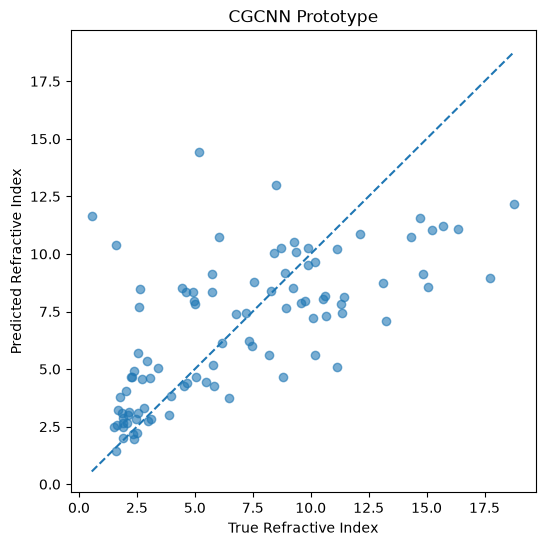

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    results["true"],
    results["pred"],
    alpha=0.6
)

xmin = results["true"].min()
xmax = results["true"].max()

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    "--"
)

plt.xlabel("True Refractive Index")
plt.ylabel("Predicted Refractive Index")
plt.title("CGCNN Prototype")

plt.show()

In [85]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

print(len(train_df) + len(val_df) + len(test_df))

(22630, 4)
(4858, 4)
(4853, 4)
32341


In [87]:
from pathlib import Path
import pandas as pd
import numpy as np
from pymatgen.io.cif import CifWriter

cgcnn_full = Path(
    "/Users/anitanam/optical_materials_ml/notebooks/data/processed/cgcnn_full"
)

cgcnn_full.mkdir(parents=True, exist_ok=True)

In [88]:
import shutil

shutil.copy(
    "/Users/anitanam/venvs/alignn23/lib/python3.9/site-packages/jarvis/core/atom_init.json",
    cgcnn_full / "atom_init.json"
)

PosixPath('/Users/anitanam/optical_materials_ml/notebooks/data/processed/cgcnn_full/atom_init.json')

In [89]:
full_df = pd.concat(
    [
        train_df[["jid", "refractive_index", "atoms"]],
        val_df[["jid", "refractive_index", "atoms"]],
        test_df[["jid", "refractive_index", "atoms"]],
    ],
    ignore_index=True
)

print(full_df.shape)

(32341, 3)


In [90]:
rows = []

for _, row in full_df.iterrows():
    rows.append(
        [
            row["jid"],
            float(row["refractive_index"])
        ]
    )

pd.DataFrame(rows).to_csv(
    cgcnn_full / "id_prop.csv",
    header=False,
    index=False
)

print("rows:", len(rows))

rows: 32341


In [91]:
from tqdm import tqdm

for _, row in tqdm(full_df.iterrows(), total=len(full_df)):
    struct = atoms_dict_to_structure(row["atoms"])

    CifWriter(struct).write_file(
        str(cgcnn_full / f"{row['jid']}.cif")
    )

 51%|█████     | 16365/32341 [00:05<00:04, 3265.45it/s]/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
 52%|█████▏    | 16697/32341 [00:05<00:04, 3280.23it/s]/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
100%|██████████| 32341/32341 [00:10<00:00, 3130.34it/s]


In [92]:
import os

print((cgcnn_full / "atom_init.json").exists())
print((cgcnn_full / "id_prop.csv").exists())

print(
    len(
        [
            f for f in os.listdir(cgcnn_full)
            if f.endswith(".cif")
        ]
    )
)

True
True
32045


In [94]:
cd ~/cgcnn

python3 main.py \
  --task regression \
  --disable-cuda \
  --train-size 22630 \
  --val-size 4858 \
  --test-size 4853 \
  /Users/anitanam/optical_materials_ml/notebooks/data/processed/cgcnn_full

SyntaxError: invalid syntax (118481915.py, line 1)

In [95]:
print(len(full_df))
print(
    len([
        f for f in os.listdir(cgcnn_full)
        if f.endswith(".cif")
    ])
)

32341
32045


In [96]:
expected = set(full_df["jid"])
actual = set(
    f.replace(".cif", "")
    for f in os.listdir(cgcnn_full)
    if f.endswith(".cif")
)

print("Missing:", len(expected - actual))
list(expected - actual)[:20]

Missing: 0


[]

In [97]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = pd.read_csv(
    "/Users/anitanam/cgcnn/test_results.csv",
    header=None,
    names=["jid", "true", "pred"]
)

mae = mean_absolute_error(results["true"], results["pred"])
rmse = np.sqrt(mean_squared_error(results["true"], results["pred"]))
r2 = r2_score(results["true"], results["pred"])

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.7142328032200886
RMSE: 2.487717180873636
R²  : 0.664226206248836


In [98]:
import pandas as pd
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

# full_df should have columns like jid, reduced_formula, refractive_index
ep = ElementProperty.from_preset("magpie")

def formula_to_magpie(formula):
    comp = Composition(formula)
    return ep.featurize(comp)

magpie_cols = ep.feature_labels()

magpie_rows = []
for _, row in full_df.iterrows():
    feats = formula_to_magpie(row["reduced_formula"])
    magpie_rows.append([row["jid"], *feats])

magpie_df = pd.DataFrame(magpie_rows, columns=["jid", *magpie_cols])

print(magpie_df.shape)
print(magpie_df.head())

/opt/homebrew/Cellar/jupyterlab/4.5.8_1/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyError: 'reduced_formula'

In [99]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# Rebuild full table if needed
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

ep = ElementProperty.from_preset("magpie")
magpie_cols = ep.feature_labels()

formula_df = full_df[["jid", "refractive_index", "reduced_formula"]].copy()
formula_df["composition"] = formula_df["reduced_formula"].map(Composition)

feats = []
for comp in tqdm(formula_df["composition"], total=len(formula_df)):
    feats.append(ep.featurize(comp))

magpie_df = pd.DataFrame(feats, columns=magpie_cols)
magpie_df.insert(0, "jid", formula_df["jid"].values)
magpie_df.insert(1, "refractive_index", formula_df["refractive_index"].values)

print(magpie_df.shape)
print(magpie_df.head())

100%|██████████| 32341/32341 [00:17<00:00, 1804.74it/s]


(32341, 134)
           jid  refractive_index  MagpieData minimum Number  \
0  JVASP-90856          8.296590                       14.0   
1  JVASP-86097         11.873256                        5.0   
2  JVASP-64906         14.027763                        4.0   
3  JVASP-64664         10.828656                       11.0   
4  JVASP-86726         15.273380                       28.0   

   MagpieData maximum Number  MagpieData range Number  MagpieData mean Number  \
0                       33.0                     19.0               24.500000   
1                       66.0                     61.0               13.714286   
2                       76.0                     72.0               32.000000   
3                       83.0                     72.0               53.000000   
4                       71.0                     43.0               38.833333   

   MagpieData avg_dev Number  MagpieData mode Number  \
0                   6.500000                    14.0   
1        

In [100]:
# Merge Magpie features back onto your existing splits
train_mag = train_df[["jid", "refractive_index"]].merge(magpie_df, on="jid", how="inner")
val_mag = val_df[["jid", "refractive_index"]].merge(magpie_df, on="jid", how="inner")
test_mag = test_df[["jid", "refractive_index"]].merge(magpie_df, on="jid", how="inner")

print(train_mag.shape, val_mag.shape, test_mag.shape)

(23040, 135) (4960, 135) (4947, 135)


In [102]:
print(train_mag.columns.tolist()[:10])
print([c for c in train_mag.columns if "refractive" in c])

['jid', 'refractive_index_x', 'refractive_index_y', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber']
['refractive_index_x', 'refractive_index_y']


In [103]:
# keep the target from the split table and drop any duplicate target column from Magpie merge
train_mag = train_mag.rename(columns={"refractive_index_x": "refractive_index"}).drop(
    columns=[c for c in train_mag.columns if c == "refractive_index_y"],
    errors="ignore",
)

val_mag = val_mag.rename(columns={"refractive_index_x": "refractive_index"}).drop(
    columns=[c for c in val_mag.columns if c == "refractive_index_y"],
    errors="ignore",
)

test_mag = test_mag.rename(columns={"refractive_index_x": "refractive_index"}).drop(
    columns=[c for c in test_mag.columns if c == "refractive_index_y"],
    errors="ignore",
)

In [104]:
def fix_target_column(df):
    cols = df.columns.tolist()
    target_cols = [c for c in cols if "refractive_index" in c]
    print("target-like columns:", target_cols)
    if "refractive_index" not in cols:
        if "refractive_index_x" in cols:
            df = df.rename(columns={"refractive_index_x": "refractive_index"})
        elif "refractive_index_y" in cols:
            df = df.rename(columns={"refractive_index_y": "refractive_index"})
    drop_cols = [c for c in df.columns if c.endswith("_x") or c.endswith("_y")]
    return df.drop(columns=drop_cols, errors="ignore")

train_mag = fix_target_column(train_mag)
val_mag = fix_target_column(val_mag)
test_mag = fix_target_column(test_mag)

target-like columns: ['refractive_index']
target-like columns: ['refractive_index']
target-like columns: ['refractive_index']


In [105]:
X_train = train_mag.drop(columns=["jid", "refractive_index"], errors="ignore")
y_train = train_mag["refractive_index"]

X_val = val_mag.drop(columns=["jid", "refractive_index"], errors="ignore")
y_val = val_mag["refractive_index"]

X_test = test_mag.drop(columns=["jid", "refractive_index"], errors="ignore")
y_test = test_mag["refractive_index"]

In [106]:
def fix_target_column(df):
    df = df.copy()

    # rename whichever target column exists
    if "refractive_index" not in df.columns:
        if "refractive_index_x" in df.columns:
            df = df.rename(columns={"refractive_index_x": "refractive_index"})
        elif "refractive_index_y" in df.columns:
            df = df.rename(columns={"refractive_index_y": "refractive_index"})

    # drop any leftover merge suffix columns
    drop_cols = [c for c in df.columns if c.endswith("_x") or c.endswith("_y")]
    df = df.drop(columns=drop_cols, errors="ignore")

    return df

train_mag = fix_target_column(train_mag)
val_mag = fix_target_column(val_mag)
test_mag = fix_target_column(test_mag)

print([c for c in train_mag.columns if "refractive" in c])

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train = train_mag.drop(columns=["jid", "refractive_index"], errors="ignore")
y_train = train_mag["refractive_index"]

X_test = test_mag.drop(columns=["jid", "refractive_index"], errors="ignore")
y_test = test_mag["refractive_index"]

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

['refractive_index']
MAE : 1.6620656158984621
RMSE: 2.409881166652533
R²  : 0.6824760108556369


In [107]:
cgcnn_preds = pd.read_csv(
    "/Users/anitanam/cgcnn/test_results.csv",
    header=None,
    names=["jid", "true", "cgcnn_pred"]
)

print(cgcnn_preds.head())
print(cgcnn_preds.shape)

            jid       true  cgcnn_pred
0   JVASP-14587   8.196030    7.664264
1   JVASP-38548  10.276026   10.617806
2  JVASP-102878   2.459349    2.376572
3   JVASP-18984   2.246412    2.235533
4   JVASP-15993  11.797993    9.828053
(4853, 3)


In [108]:
hybrid_test = test_mag.merge(
    cgcnn_preds[["jid", "cgcnn_pred"]],
    on="jid",
    how="inner"
)

print(hybrid_test.shape)
print(hybrid_test.head())

(750, 135)
           jid  refractive_index  MagpieData minimum Number  \
0   JVASP-3828          4.643339                       17.0   
1  JVASP-48383          3.917240                        8.0   
2  JVASP-85665          2.191947                        1.0   
3  JVASP-64316         16.640240                       26.0   
4  JVASP-36885          4.231564                        9.0   

   MagpieData maximum Number  MagpieData range Number  MagpieData mean Number  \
0                       43.0                     26.0               20.333333   
1                       26.0                     18.0               12.000000   
2                       56.0                     55.0               14.444444   
3                       56.0                     30.0               48.500000   
4                       81.0                     72.0               27.000000   

   MagpieData avg_dev Number  MagpieData mode Number  \
0                   5.037037                    17.0   
1          

In [109]:
train_mag["cgcnn_proxy"] = model.predict(
    train_mag.drop(columns=["jid", "refractive_index"])
)

val_mag["cgcnn_proxy"] = model.predict(
    val_mag.drop(columns=["jid", "refractive_index"])
)

test_mag["cgcnn_proxy"] = hybrid_test["cgcnn_pred"].values

ValueError: Length of values (750) does not match length of index (4947)

In [110]:
print(test_mag.shape)
print(hybrid_test.shape)

print(len(test_mag))
print(len(hybrid_test))

(4947, 134)
(750, 135)
4947
750


In [111]:
print(cgcnn_preds.shape)
print(cgcnn_preds.head())

(4853, 3)
            jid       true  cgcnn_pred
0   JVASP-14587   8.196030    7.664264
1   JVASP-38548  10.276026   10.617806
2  JVASP-102878   2.459349    2.376572
3   JVASP-18984   2.246412    2.235533
4   JVASP-15993  11.797993    9.828053


In [112]:
print(test_mag[["jid"]].head())

           jid
0  JVASP-64003
1  JVASP-64719
2  JVASP-64314
3  JVASP-64512
4  JVASP-91520


In [113]:
print("train_mag:", train_mag.shape)
print("val_mag:", val_mag.shape)
print("test_mag:", test_mag.shape)

print([c for c in train_mag.columns if "refractive" in c])

train_mag: (23040, 135)
val_mag: (4960, 135)
test_mag: (4947, 134)
['refractive_index']


In [114]:
# 1) Check for duplicate JIDs first
for name, df in [("train_mag", train_mag), ("val_mag", val_mag), ("test_mag", test_mag)]:
    print(name, "rows:", len(df), "unique jid:", df["jid"].nunique(), "duplicates:", df["jid"].duplicated().sum())

print("cgcnn_preds rows:", len(cgcnn_preds), "unique jid:", cgcnn_preds["jid"].nunique())

train_mag rows: 23040 unique jid: 22431 duplicates: 609
val_mag rows: 4960 unique jid: 4807 duplicates: 153
test_mag rows: 4947 unique jid: 4807 duplicates: 140
cgcnn_preds rows: 4853 unique jid: 4848


In [115]:
# 2) Build a clean overlap set: only JIDs present in both Magpie test and CGCNN test predictions
train_mag_u = train_mag.drop_duplicates("jid").copy()
val_mag_u = val_mag.drop_duplicates("jid").copy()
test_mag_u = test_mag.drop_duplicates("jid").copy()
cgcnn_preds_u = cgcnn_preds.drop_duplicates("jid").copy()

hybrid = test_mag_u.merge(
    cgcnn_preds_u[["jid", "cgcnn_pred"]],
    on="jid",
    how="inner",
    validate="one_to_one",
)

print(hybrid.shape)
print(hybrid.head())

(720, 135)
           jid  refractive_index  MagpieData minimum Number  \
0   JVASP-3828          4.643339                       17.0   
1  JVASP-48383          3.917240                        8.0   
2  JVASP-85665          2.191947                        1.0   
3  JVASP-64316         16.640240                       26.0   
4  JVASP-36885          4.231564                        9.0   

   MagpieData maximum Number  MagpieData range Number  MagpieData mean Number  \
0                       43.0                     26.0               20.333333   
1                       26.0                     18.0               12.000000   
2                       56.0                     55.0               14.444444   
3                       56.0                     30.0               48.500000   
4                       81.0                     72.0               27.000000   

   MagpieData avg_dev Number  MagpieData mode Number  \
0                   5.037037                    17.0   
1          

In [116]:
# 3) Train a Magpie-only model and a hybrid model on that same overlap set
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# target
y = hybrid["refractive_index"]

# Magpie-only features
X_mag = hybrid.drop(columns=["jid", "refractive_index", "cgcnn_pred"])

# Hybrid features
X_hyb = hybrid.drop(columns=["jid", "refractive_index"])

X_mag_train, X_mag_test, y_train, y_test = train_test_split(
    X_mag, y, test_size=0.2, random_state=42
)

X_hyb_train, X_hyb_test, _, _ = train_test_split(
    X_hyb, y, test_size=0.2, random_state=42
)

mag_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

hyb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

mag_model.fit(X_mag_train, y_train)
hyb_model.fit(X_hyb_train, y_train)

mag_pred = mag_model.predict(X_mag_test)
hyb_pred = hyb_model.predict(X_hyb_test)

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print()

report("Magpie-only", y_test, mag_pred)
report("Magpie + CGCNN", y_test, hyb_pred)

Magpie-only
MAE : 2.2079710275419697
RMSE: 3.12367690817716
R²  : 0.49208673723004315

Magpie + CGCNN
MAE : 1.7705085230733044
RMSE: 2.6383085828373427
R²  : 0.6376664743804485



In [117]:
# Run these three cells

# 1. Check duplicates
for name, df in [("train_mag", train_mag), ("val_mag", val_mag), ("test_mag", test_mag)]:
    print(name, "rows:", len(df), "unique jid:", df["jid"].nunique(), "duplicates:", df["jid"].duplicated().sum())

print("cgcnn_preds rows:", len(cgcnn_preds), "unique jid:", cgcnn_preds["jid"].nunique())

train_mag rows: 23040 unique jid: 22431 duplicates: 609
val_mag rows: 4960 unique jid: 4807 duplicates: 153
test_mag rows: 4947 unique jid: 4807 duplicates: 140
cgcnn_preds rows: 4853 unique jid: 4848


In [118]:
# 2. Build overlap set
train_mag_u = train_mag.drop_duplicates("jid").copy()
val_mag_u = val_mag.drop_duplicates("jid").copy()
test_mag_u = test_mag.drop_duplicates("jid").copy()
cgcnn_preds_u = cgcnn_preds.drop_duplicates("jid").copy()

hybrid = test_mag_u.merge(
    cgcnn_preds_u[["jid", "cgcnn_pred"]],
    on="jid",
    how="inner",
    validate="one_to_one",
)

print(hybrid.shape)

(720, 135)


In [119]:
print(train_df.columns.tolist())

['jid', 'reduced_formula', 'refractive_index', 'atoms']


In [120]:
print(len(train_df.columns))

4


In [121]:
print(train_df.shape)
print(len(train_df.columns))
print(train_df.columns.tolist())

(22630, 4)
4
['jid', 'reduced_formula', 'refractive_index', 'atoms']


In [122]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if (
            "magpie" in f.lower()
            or "feature" in f.lower()
            or "descriptor" in f.lower()
            or f.endswith(".parquet")
        ):
            print(os.path.join(root, f))

./02_feature_engineering.ipynb
./results/rf_feature_importance.csv
./.ipynb_checkpoints/02_feature_engineering-checkpoint.ipynb
./data/processed/ri_structure_dataset_clean.parquet
./data/processed/ri_master.parquet
./data/processed/lignn_train_proto_manifest.parquet
./data/processed/ri_structure_dataset_lignn.parquet
./data/processed/ri_structure_dataset_cgcnn.parquet
./data/processed/ri_cgcnn_ready.parquet
./data/processed/bandgap_train.parquet
./data/processed/ri_cgcnn_ready_clean.parquet
./data/processed/lignn_test_with_atoms.parquet
./data/processed/cgcnn_val.parquet
./data/processed/lignn_train_ready_final.parquet
./data/processed/lignn_test_manifest.parquet
./data/processed/lignn_train_ready.parquet
./data/processed/lignn_val_with_atoms.parquet
./data/processed/lignn_train_proto.parquet
./data/processed/ri_structure_dataset.parquet
./data/processed/lignn_train_ready_v2.parquet
./data/processed/lignn_val.parquet
./data/processed/lignn_val_manifest.parquet
./data/processed/lignn_te

In [123]:
import pandas as pd

ri_feat = pd.read_parquet("data/processed/refractive_index_features.parquet")
ri_final = pd.read_parquet("data/processed/ri_final.parquet")
ri_density = pd.read_parquet("data/processed/ri_final_with_density.parquet")

print("refractive_index_features:", ri_feat.shape)
print("ri_final:", ri_final.shape)
print("ri_final_with_density:", ri_density.shape)

print("\nrefractive_index_features columns:")
print(ri_feat.columns[:20].tolist())

print("\nri_final columns:")
print(ri_final.columns[:20].tolist())

print("\nri_final_with_density columns:")
print(ri_density.columns[:20].tolist())

refractive_index_features: (37626, 134)
ri_final: (32341, 141)
ri_final_with_density: (32341, 141)

refractive_index_features columns:
['reduced_formula', 'refractive_index', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight']

ri_final columns:
['reduced_formula', 'refractive_index', 'optb88vdw_bandgap', 'formation_energy_peratom', 'ehull', 'epsx', 'epsy', 'epsz', 'density', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 

In [124]:
print("Features file column count:", len(ri_feat.columns))
print("ri_final column count:", len(ri_final.columns))
print("ri_final_with_density column count:", len(ri_density.columns))

Features file column count: 134
ri_final column count: 141
ri_final_with_density column count: 141


In [125]:
print(ri_final.columns[:20].tolist())

possible_ids = [
    c for c in ri_final.columns
    if "jid" in c.lower()
    or "id" == c.lower()
]

print(possible_ids)

['reduced_formula', 'refractive_index', 'optb88vdw_bandgap', 'formation_energy_peratom', 'ehull', 'epsx', 'epsy', 'epsz', 'density', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber']
[]


In [126]:
print(cgcnn_preds.columns)

Index(['jid', 'true', 'cgcnn_pred'], dtype='object')


In [127]:
import pandas as pd

base = pd.read_parquet("data/processed/ri_structure_dataset_clean.parquet")[["jid", "reduced_formula", "refractive_index"]].reset_index(drop=True)
desc = pd.read_parquet("data/processed/ri_final.parquet").reset_index(drop=True)

print("base shape:", base.shape)
print("desc shape:", desc.shape)

print("formula match rate:", (base["reduced_formula"] == desc["reduced_formula"]).mean())
print("target match rate:", (base["refractive_index"].round(6) == desc["refractive_index"].round(6)).mean())

base shape: (32341, 3)
desc shape: (32341, 141)
formula match rate: 1.0
target match rate: 1.0


In [128]:
ri_desc = pd.concat([base[["jid"]], desc], axis=1)

print(ri_desc.shape)
print(ri_desc.columns[:10].tolist())
print(ri_desc[["jid", "reduced_formula", "refractive_index"]].head())

(32341, 142)
['jid', 'reduced_formula', 'refractive_index', 'optb88vdw_bandgap', 'formation_energy_peratom', 'ehull', 'epsx', 'epsy', 'epsz', 'density']
           jid reduced_formula  refractive_index
0  JVASP-90856        TiCuSiAs          8.296590
1  JVASP-86097            DyB6         11.873256
2  JVASP-64906         Be2OsRu         14.027763
3  JVASP-64664         Ba4NaBi         10.828656
4  JVASP-86726         LuNi4Sn         15.273380


In [129]:
cgcnn_preds = pd.read_csv(
    "/Users/anitanam/cgcnn/test_results.csv",
    header=None,
    names=["jid", "true", "cgcnn_pred"]
).drop_duplicates("jid")

hybrid_full = ri_desc.merge(cgcnn_preds[["jid", "cgcnn_pred"]], on="jid", how="inner")

print(hybrid_full.shape)
print(hybrid_full.head())

(4923, 143)
            jid reduced_formula  refractive_index  optb88vdw_bandgap  \
0   JVASP-64664         Ba4NaBi         10.828656              0.000   
1  JVASP-107772           Bi3Sb          7.130383              0.000   
2    JVASP-3828         K2TcCl6          4.643339              0.995   
3   JVASP-63913          Ba4YRh         14.459333              0.000   
4   JVASP-48383         NaFePO4          3.917240              0.000   

   formation_energy_peratom   ehull      epsx      epsy      epsz   density  \
0                   0.09202  0.5443  117.2598  117.2598  117.2598       NaN   
1                  -0.00064  0.0040   55.2309   55.9936   41.3026       NaN   
2                  -1.41944  0.0000   21.5606   21.5606   21.5606  2.723327   
3                   0.81326  1.1203  209.0723  209.0723  209.0723       NaN   
4                  -1.99266  0.0165   11.3496   17.1384   17.5463  3.625928   

   ...  MagpieData mean GSmagmom  MagpieData avg_dev GSmagmom  \
0  ...         

In [130]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

hybrid_full = hybrid_full.dropna().copy()

y = hybrid_full["refractive_index"]
X_desc = hybrid_full.drop(columns=["jid", "refractive_index", "cgcnn_pred"])
X_hyb = hybrid_full.drop(columns=["jid", "refractive_index"])

X_desc_train, X_desc_test, y_train, y_test = train_test_split(X_desc, y, test_size=0.2, random_state=42)
X_hyb_train, X_hyb_test, _, _ = train_test_split(X_hyb, y, test_size=0.2, random_state=42)

desc_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

hyb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

desc_model.fit(X_desc_train, y_train)
hyb_model.fit(X_hyb_train, y_train)

desc_pred = desc_model.predict(X_desc_test)
hyb_pred = hyb_model.predict(X_hyb_test)

def report(name, yt, yp):
    print(name)
    print("MAE :", mean_absolute_error(yt, yp))
    print("RMSE:", np.sqrt(mean_squared_error(yt, yp)))
    print("R²  :", r2_score(yt, yp))
    print()

report("Descriptor-only", y_test, desc_pred)
report("Descriptor + CGCNN", y_test, hyb_pred)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:reduced_formula: object

In [131]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Show the non-numeric columns first
print("Non-numeric descriptor columns:", hybrid_full.drop(columns=["jid", "refractive_index", "cgcnn_pred"]).select_dtypes(exclude=np.number).columns.tolist())

# Keep only numeric features
X_desc = hybrid_full.drop(columns=["jid", "refractive_index", "cgcnn_pred"]).select_dtypes(include=[np.number]).copy()
X_hyb = hybrid_full.drop(columns=["jid", "refractive_index"]).select_dtypes(include=[np.number]).copy()
y = hybrid_full["refractive_index"].copy()

print("Descriptor feature shape:", X_desc.shape)
print("Hybrid feature shape:", X_hyb.shape)

X_desc_train, X_desc_test, y_train, y_test = train_test_split(
    X_desc, y, test_size=0.2, random_state=42
)
X_hyb_train, X_hyb_test, _, _ = train_test_split(
    X_hyb, y, test_size=0.2, random_state=42
)

desc_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

hyb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

desc_model.fit(X_desc_train, y_train)
hyb_model.fit(X_hyb_train, y_train)

desc_pred = desc_model.predict(X_desc_test)
hyb_pred = hyb_model.predict(X_hyb_test)

def report(name, yt, yp):
    print(name)
    print("MAE :", mean_absolute_error(yt, yp))
    print("RMSE:", np.sqrt(mean_squared_error(yt, yp)))
    print("R²  :", r2_score(yt, yp))
    print()

report("Descriptor-only", y_test, desc_pred)
report("Descriptor + CGCNN", y_test, hyb_pred)

Non-numeric descriptor columns: ['reduced_formula']
Descriptor feature shape: (1215, 139)
Hybrid feature shape: (1215, 140)
Descriptor-only
MAE : 0.048548907833920976
RMSE: 0.13885105227886363
R²  : 0.9939905027638885

Descriptor + CGCNN
MAE : 0.04190928814955139
RMSE: 0.12907842643316267
R²  : 0.9948066557234582



In [132]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base = pd.read_parquet("data/processed/ri_structure_dataset_clean.parquet")[["jid", "reduced_formula", "refractive_index"]].reset_index(drop=True)
desc = pd.read_parquet("data/processed/ri_final.parquet").reset_index(drop=True)

ri_desc = pd.concat([base[["jid"]], desc], axis=1)

# remove near-target dielectric tensor columns for a fairer baseline
fair_drop = [c for c in ri_desc.columns if c.startswith("eps")]
fair_drop += ["reduced_formula"]  # keep only numeric features for XGBoost

fair_df = ri_desc.drop(columns=fair_drop, errors="ignore").copy()

cgcnn_preds_u = cgcnn_preds.drop_duplicates("jid").copy()
hybrid_full = fair_df.merge(cgcnn_preds_u[["jid", "cgcnn_pred"]], on="jid", how="inner").copy()

print("fair_df:", fair_df.shape)
print("hybrid_full:", hybrid_full.shape)
print([c for c in hybrid_full.columns if "eps" in c.lower()])

fair_df: (32341, 138)
hybrid_full: (4923, 139)
[]


In [133]:
X_desc = hybrid_full.drop(columns=["jid", "refractive_index", "cgcnn_pred"]).select_dtypes(include=[np.number]).copy()
X_hyb = hybrid_full.drop(columns=["jid", "refractive_index"]).select_dtypes(include=[np.number]).copy()
y = hybrid_full["refractive_index"].copy()

X_desc_train, X_desc_test, y_train, y_test = train_test_split(
    X_desc, y, test_size=0.2, random_state=42
)
X_hyb_train, X_hyb_test, _, _ = train_test_split(
    X_hyb, y, test_size=0.2, random_state=42
)

desc_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

hyb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

desc_model.fit(X_desc_train, y_train)
hyb_model.fit(X_hyb_train, y_train)

desc_pred = desc_model.predict(X_desc_test)
hyb_pred = hyb_model.predict(X_hyb_test)

def report(name, yt, yp):
    print(name)
    print("MAE :", mean_absolute_error(yt, yp))
    print("RMSE:", np.sqrt(mean_squared_error(yt, yp)))
    print("R²  :", r2_score(yt, yp))
    print()

report("Descriptor-only (fair)", y_test, desc_pred)
report("Descriptor + CGCNN (fair)", y_test, hyb_pred)

Descriptor-only (fair)
MAE : 1.7300824519173736
RMSE: 2.495987665673077
R²  : 0.6648525599330573

Descriptor + CGCNN (fair)
MAE : 1.5403854764364557
RMSE: 2.369738365617461
R²  : 0.6978992271989092



In [136]:
import sys
print(sys.executable)

/opt/homebrew/Cellar/jupyterlab/4.5.8_1/libexec/bin/python


In [141]:
import pandas as pd

cgcnn_emb = pd.read_parquet(
    "/Users/anitanam/optical_materials_ml/notebooks/data/processed/cgcnn_full/cgcnn_embeddings.parquet"
)

base = pd.read_parquet("data/processed/ri_structure_dataset_clean.parquet")[["jid", "reduced_formula", "refractive_index"]].reset_index(drop=True)
desc = pd.read_parquet("data/processed/ri_final.parquet").reset_index(drop=True)

ri_desc = pd.concat([base[["jid"]], desc], axis=1)

drop_cols = [c for c in ri_desc.columns if c.startswith("eps")] + ["reduced_formula"]
ri_desc_fair = ri_desc.drop(columns=drop_cols, errors="ignore")

fusion = ri_desc_fair.merge(cgcnn_emb.drop(columns=["refractive_index_cgcnn"]), on="jid", how="inner")

print(cgcnn_emb.shape)
print(ri_desc_fair.shape)
print(fusion.shape)
print(fusion.head())

(32341, 130)
(32341, 138)
(32947, 266)
           jid  refractive_index  optb88vdw_bandgap  formation_energy_peratom  \
0  JVASP-90856          8.296590                0.0                  -0.42762   
1  JVASP-86097         11.873256                0.0                  -0.41596   
2  JVASP-64906         14.027763                0.0                   0.04847   
3  JVASP-64664         10.828656                0.0                   0.09202   
4  JVASP-86726         15.273380                0.0                  -0.42539   

    ehull  density  MagpieData minimum Number  MagpieData maximum Number  \
0  0.0423      NaN                       14.0                       33.0   
1  0.0456      NaN                        5.0                       66.0   
2  0.3183      NaN                        4.0                       76.0   
3  0.5443      NaN                       11.0                       83.0   
4  0.0000      NaN                       28.0                       71.0   

   MagpieData ran

In [142]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make sure every jid appears once
cgcnn_emb_u = cgcnn_emb.drop_duplicates("jid").copy()
ri_desc_u = ri_desc_fair.drop_duplicates("jid").copy()

fusion_u = ri_desc_u.merge(
    cgcnn_emb_u.drop(columns=["refractive_index_cgcnn"]),
    on="jid",
    how="inner",
    validate="one_to_one"
)

print("cgcnn_emb_u:", cgcnn_emb_u.shape)
print("ri_desc_u:", ri_desc_u.shape)
print("fusion_u:", fusion_u.shape)
print("duplicate jids in fusion:", fusion_u["jid"].duplicated().sum())

cgcnn_emb_u: (32045, 130)
ri_desc_u: (32045, 138)
fusion_u: (32045, 266)
duplicate jids in fusion: 0


In [143]:
# Drop non-numeric columns and target
X_desc = fusion_u.drop(columns=["jid", "refractive_index"]).select_dtypes(include=[np.number]).copy()
y = fusion_u["refractive_index"].copy()

# Multimodal feature set = descriptors + CGCNN embedding
X_mm = X_desc.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_mm, y, test_size=0.2, random_state=42
)

mm_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

mm_model.fit(X_train, y_train)
pred = mm_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Multimodal MAE :", mae)
print("Multimodal RMSE:", rmse)
print("Multimodal R²  :", r2)

Multimodal MAE : 1.2944070136363246
Multimodal RMSE: 1.9763096773150164
Multimodal R²  : 0.7861448222131923


In [144]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Recreate test predictions with the fitted multimodal model
test_results = X_test.copy()
test_results["true_refractive_index"] = y_test.values
test_results["pred_refractive_index"] = pred
test_results["abs_error"] = np.abs(test_results["true_refractive_index"] - test_results["pred_refractive_index"])

# Save predictions
test_results.to_csv(
    "data/processed/multimodal_test_predictions.csv",
    index=False
)

# Save a compact metrics summary
summary = pd.DataFrame([
    {
        "model": "multimodal_fusion",
        "mae": mean_absolute_error(y_test, pred),
        "rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "r2": r2_score(y_test, pred),
        "n_test": len(y_test),
    }
])

summary.to_csv("data/processed/multimodal_metrics.csv", index=False)

print(summary)
print("Saved test predictions and metrics.")

               model       mae     rmse        r2  n_test
0  multimodal_fusion  1.294407  1.97631  0.786145    6409
Saved test predictions and metrics.


In [145]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mm = pd.read_csv("data/processed/multimodal_test_predictions.csv")

mae = mean_absolute_error(mm["true_refractive_index"], mm["pred_refractive_index"])
rmse = np.sqrt(mean_squared_error(mm["true_refractive_index"], mm["pred_refractive_index"]))
r2 = r2_score(mm["true_refractive_index"], mm["pred_refractive_index"])

summary = pd.DataFrame([
    {"model": "descriptor_only_fair", "mae": 1.7300824519173736, "rmse": 2.495987665673077, "r2": 0.6648525599330573},
    {"model": "cgcnn_only", "mae": 1.7142328032200886, "rmse": 2.487717180873636, "r2": 0.664226206248836},
    {"model": "multimodal_fusion", "mae": mae, "rmse": rmse, "r2": r2},
]).sort_values("r2", ascending=False)

print(summary)
summary.to_csv("data/processed/final_model_comparison.csv", index=False)

                  model       mae      rmse        r2
2     multimodal_fusion  1.294407  1.976310  0.786145
0  descriptor_only_fair  1.730082  2.495988  0.664853
1            cgcnn_only  1.714233  2.487717  0.664226


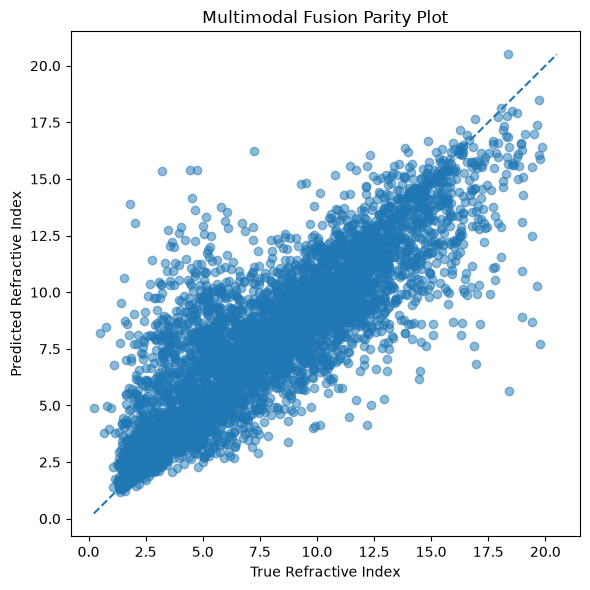

In [146]:
import matplotlib.pyplot as plt

true = mm["true_refractive_index"]
pred = mm["pred_refractive_index"]

plt.figure(figsize=(6, 6))
plt.scatter(true, pred, alpha=0.5)
lo = min(true.min(), pred.min())
hi = max(true.max(), pred.max())
plt.plot([lo, hi], [lo, hi], "--")
plt.xlabel("True Refractive Index")
plt.ylabel("Predicted Refractive Index")
plt.title("Multimodal Fusion Parity Plot")
plt.tight_layout()
plt.show()

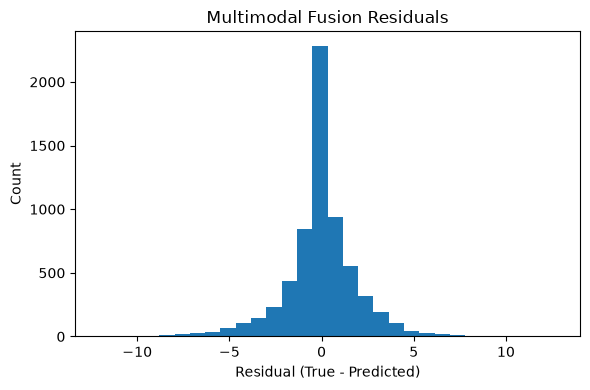

In [147]:
plt.figure(figsize=(6, 4))
residuals = true - pred
plt.hist(residuals, bins=30)
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Count")
plt.title("Multimodal Fusion Residuals")
plt.tight_layout()
plt.show()

In [148]:
# Quick error inspection
mm["abs_error"] = (mm["true_refractive_index"] - mm["pred_refractive_index"]).abs()
print(mm.sort_values("abs_error", ascending=False).head(15))

      optb88vdw_bandgap  formation_energy_peratom   ehull  density  \
5342                0.0                   0.29630  0.2963      NaN   
966                 0.0                   0.04007  0.0584      NaN   
2664                0.0                  -0.76537  0.0000      NaN   
4372                0.0                  -0.97758  0.0000      NaN   
4136                0.0                   0.00007  0.0831      NaN   
4450                0.0                   0.12758  0.1363      NaN   
2519                0.0                  -0.09583  0.2698      NaN   
4355                0.0                  -0.27284  0.0118      NaN   
1693                0.0                  -0.14330  0.0356      NaN   
3362                0.0                   0.12445  0.1926      NaN   
4248                0.0                  -0.52783  0.0000      NaN   
4998                0.0                  -0.05029  0.0301      NaN   
1612                0.0                  -0.93614  0.0000      NaN   
4194                

In [149]:
import pandas as pd

comp = pd.read_csv("data/processed/final_model_comparison.csv")
comp

,model,mae,rmse,r2
0,multimodal_fusion,1.294407,1.976310,0.786145
1,descriptor_only_fair,1.730082,2.495988,0.664853
2,cgcnn_only,1.714233,2.487717,0.664226


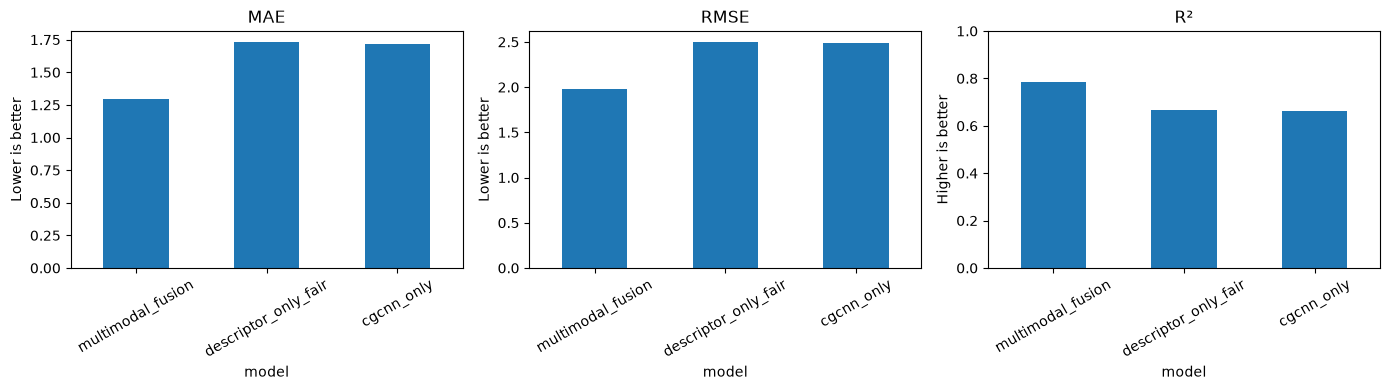

In [150]:
import matplotlib.pyplot as plt

metrics = comp.set_index("model")[["mae", "rmse", "r2"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics["mae"].plot(kind="bar", ax=axes[0])
axes[0].set_title("MAE")
axes[0].set_ylabel("Lower is better")

metrics["rmse"].plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE")
axes[1].set_ylabel("Lower is better")

metrics["r2"].plot(kind="bar", ax=axes[2])
axes[2].set_title("R²")
axes[2].set_ylabel("Higher is better")
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [151]:
best = comp.sort_values("r2", ascending=False).iloc[0]
desc = comp[comp["model"] == "descriptor_only_fair"].iloc[0]
cgcnn = comp[comp["model"] == "cgcnn_only"].iloc[0]
mm = comp[comp["model"] == "multimodal_fusion"].iloc[0]

writeup = f"""
Methodology and Results Summary

We evaluated three models for refractive-index prediction. The fair descriptor-only baseline used engineered composition and property descriptors. The structure-only baseline used CGCNN predictions from crystal graphs. The multimodal model combined the descriptor features with CGCNN latent structural embeddings.

Results:
- Descriptor-only (fair): MAE = {desc.mae:.3f}, RMSE = {desc.rmse:.3f}, R² = {desc.r2:.3f}
- CGCNN-only: MAE = {cgcnn.mae:.3f}, RMSE = {cgcnn.rmse:.3f}, R² = {cgcnn.r2:.3f}
- Multimodal fusion: MAE = {mm.mae:.3f}, RMSE = {mm.rmse:.3f}, R² = {mm.r2:.3f}

The multimodal model performed best across all metrics, reducing MAE and RMSE while increasing R² relative to both single-modality baselines. This indicates that learned structural information from CGCNN adds predictive value beyond descriptor-based features alone.

Best model:
- {best.model}
- R² = {best.r2:.3f}
"""
print(writeup)

with open("data/processed/final_model_writeup.md", "w") as f:
    f.write(writeup)

print("Saved data/processed/final_model_writeup.md")


Methodology and Results Summary

We evaluated three models for refractive-index prediction. The fair descriptor-only baseline used engineered composition and property descriptors. The structure-only baseline used CGCNN predictions from crystal graphs. The multimodal model combined the descriptor features with CGCNN latent structural embeddings.

Results:
- Descriptor-only (fair): MAE = 1.730, RMSE = 2.496, R² = 0.665
- CGCNN-only: MAE = 1.714, RMSE = 2.488, R² = 0.664
- Multimodal fusion: MAE = 1.294, RMSE = 1.976, R² = 0.786

The multimodal model performed best across all metrics, reducing MAE and RMSE while increasing R² relative to both single-modality baselines. This indicates that learned structural information from CGCNN adds predictive value beyond descriptor-based features alone.

Best model:
- multimodal_fusion
- R² = 0.786

Saved data/processed/final_model_writeup.md


In [152]:
# Optional: make a compact results table for pasting into your report
comp_rounded = comp.copy()
for c in ["mae", "rmse", "r2"]:
    comp_rounded[c] = comp_rounded[c].round(3)

comp_rounded = comp_rounded.rename(columns={
    "model": "Model",
    "mae": "MAE",
    "rmse": "RMSE",
    "r2": "R²"
})

comp_rounded

,Model,MAE,RMSE,R²
0,multimodal_fusion,1.294,1.976,0.786
1,descriptor_only_fair,1.730,2.496,0.665
2,cgcnn_only,1.714,2.488,0.664


In [153]:
import joblib

joblib.dump(
    mm_model,
    "data/processed/multimodal_xgb.joblib"
)

print("Saved multimodal model")

Saved multimodal model


In [154]:
import os

os.path.exists(
    "data/processed/multimodal_xgb.joblib"
)

True

In [155]:
feature_columns = X_mm.columns.tolist()

joblib.dump(
    feature_columns,
    "data/processed/multimodal_feature_columns.joblib"
)

print(len(feature_columns))

264


In [156]:
feature_columns[:10]

['optb88vdw_bandgap',
 'formation_energy_peratom',
 'ehull',
 'density',
 'MagpieData minimum Number',
 'MagpieData maximum Number',
 'MagpieData range Number',
 'MagpieData mean Number',
 'MagpieData avg_dev Number',
 'MagpieData mode Number']

In [157]:
descriptor_columns = [
    c for c in X_mm.columns
    if not c.startswith("cgcnn_emb_")
]

joblib.dump(
    descriptor_columns,
    "data/processed/descriptor_feature_columns.joblib"
)

print(len(descriptor_columns))

136


In [158]:
embedding_columns = [
    c for c in X_mm.columns
    if c.startswith("cgcnn_emb_")
]

joblib.dump(
    embedding_columns,
    "data/processed/cgcnn_embedding_columns.joblib"
)

print(len(embedding_columns))

128


In [159]:
sample_row = X_mm.iloc[[0]].copy()

sample_row.to_parquet(
    "data/processed/sample_inference_row.parquet",
    index=False
)

sample_row.head()

,optb88vdw_bandgap,formation_energy_peratom,ehull,density,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,...,cgcnn_emb_118,cgcnn_emb_119,cgcnn_emb_120,cgcnn_emb_121,cgcnn_emb_122,cgcnn_emb_123,cgcnn_emb_124,cgcnn_emb_125,cgcnn_emb_126,cgcnn_emb_127
0,0.0,-0.42762,0.0423,NaN,14.0,33.0,19.0,24.5,6.5,14.0,...,-2.251012,-1.872432,-1.721823,-1.396724,-1.76597,-2.86924,-2.615531,-1.410453,-1.714956,-1.647387


In [160]:
import os

files = [
    "data/processed/multimodal_xgb.joblib",
    "data/processed/multimodal_feature_columns.joblib",
    "data/processed/descriptor_feature_columns.joblib",
    "data/processed/cgcnn_embedding_columns.joblib",
    "data/processed/sample_inference_row.parquet",
]

for f in files:
    print(f, os.path.exists(f))

data/processed/multimodal_xgb.joblib True
data/processed/multimodal_feature_columns.joblib True
data/processed/descriptor_feature_columns.joblib True
data/processed/cgcnn_embedding_columns.joblib True
data/processed/sample_inference_row.parquet True
